Dataset Loaded Successfully
Shape: (100, 27)

🔹 First 5 Rows:
   Intern_ID    Intern_Name  Age  Gender  \
0          1         Anitha   20  Female   
1          2         Varsha   23    Male   
2          3        Aravind   24    Male   
3          4  Uma Maheswari   23    Male   
4          5      Sathyaraj   21    Male   

                                     College_Name  Degree    Department  \
0  Sathyabama Institute of Science and Technology    B.Sc  Data Science   
1              Thiagarajar College of Engineering    B.Sc  Data Science   
2                 Rajalakshmi Engineering College     BCA            AI   
3                           Bharathiar University     MCA    Full Stack   
4           Amrita Vishwa Vidyapeetham Coimbatore  B.Tech  Data Science   

         City Internship_Mode  Intern_Duration  ... Communication_Score  \
0     Chennai          Onsite                1  ...                   1   
1  Coimbatore          Onsite                6  ...                   3 

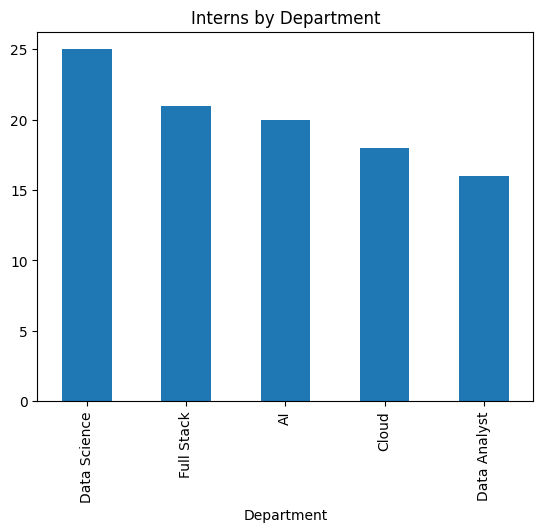

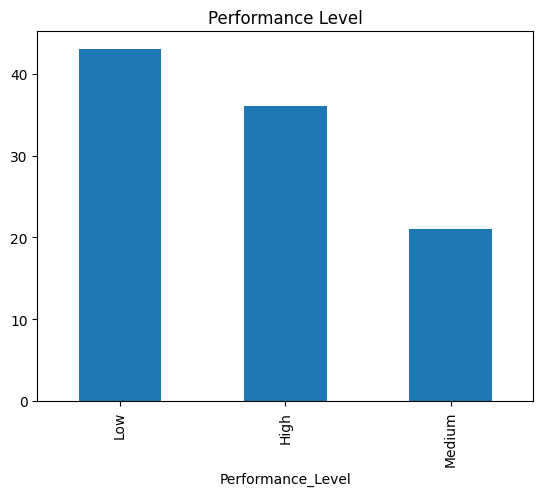

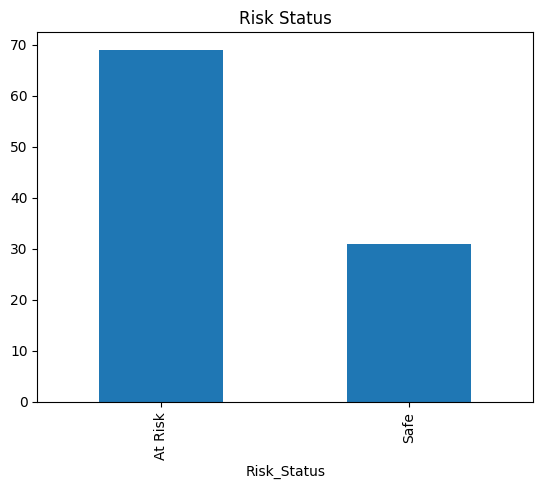


🔹 Correlation Matrix:
                          Intern_ID       Age  Intern_Duration  \
Intern_ID                  1.000000  0.232844        -0.036757   
Age                        0.232844  1.000000         0.046167   
Intern_Duration           -0.036757  0.046167         1.000000   
Tasks_Assigned            -0.011761  0.076594         0.015309   
Tasks_Completed            0.080913 -0.064144         0.199729   
Attendance_Percentage     -0.018178 -0.145489        -0.084841   
Late_Submissions          -0.110008 -0.097212        -0.039457   
Meetings_Attended         -0.113749 -0.199290        -0.001471   
Communication_Score       -0.152602 -0.220860        -0.022709   
Technical_Score            0.059261  0.005868        -0.141229   
Teamwork_Score            -0.105850  0.101664         0.031201   
Problem_Solving_Score      0.010162  0.089852        -0.168321   
Final_Performance_Rating  -0.130114 -0.001913        -0.084717   
Stipend                   -0.029989 -0.102061        

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = r"intern_dataset_cleaned.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)


print("\n🔹 First 5 Rows:")
print(df.head())

print("\n🔹 Dataset Info:")
df.info()

print("\n🔹 Missing Values:")
print(df.isnull().sum())

print("\n🔹 Statistical Summary:")
print(df.describe())


print("\n🔹 Gender Distribution:\n", df['Gender'].value_counts())
print("\n🔹 Internship Mode:\n", df['Internship_Mode'].value_counts())
print("\n🔹 Department:\n", df['Department'].value_counts())


# Task Completion %
df['Task_Completion_%'] = (df['Tasks_Completed'] / df['Tasks_Assigned']) * 100

# Performance Level
df['Performance_Level'] = df['Final_Performance_Rating'].apply(
    lambda x: 'High' if x >= 4 else ('Medium' if x == 3 else 'Low')
)


df["Risk_Status"] = df.apply(
    lambda row: "At Risk" if (
        row["Attendance_Percentage"] < 75 or
        row["Task_Completion_%"] < 60 or
        row["Final_Performance_Rating"] <= 2
    ) else "Safe",
    axis=1
)

df["Productivity_Score"] = (
    df["Task_Completion_%"] * 0.5 +
    df["Attendance_Percentage"] * 0.3 +
    (df["Final_Performance_Rating"] * 20) * 0.2
)

# Productivity Level
df["Productivity_Level"] = df["Productivity_Score"].apply(
    lambda x: "High" if x >= 75 else ("Medium" if x >= 50 else "Low")
)


print("\n KEY INSIGHTS")

print("👉 Top Department:",
      df['Department'].value_counts().idxmax())

print("👉 Average Attendance:",
      round(df['Attendance_Percentage'].mean(), 2))

print("👉 High Performers:",
      (df['Performance_Level'] == 'High').sum())

print("👉 At Risk Interns:",
      (df['Risk_Status'] == 'At Risk').sum())

print("👉 Avg Productivity Score:",
      round(df['Productivity_Score'].mean(), 2))



# Department
df['Department'].value_counts().plot(kind='bar', title="Interns by Department")
plt.show()

# Performance Level
df['Performance_Level'].value_counts().plot(kind='bar', title="Performance Level")
plt.show()

# Risk Status
df['Risk_Status'].value_counts().plot(kind='bar', title="Risk Status")
plt.show()


print("\n🔹 Correlation Matrix:")
print(df.corr(numeric_only=True))


output_path = r"intern_dataset.xlsx"
df.to_excel(output_path, index=False)

print("\n✅ Final dataset saved successfully!")

from google.colab import files
files.download("intern_final_dataset.xlsx")